# LTAT.02.006 Andmeteaduse meetodid, sügis 2025

# 6. kodutöö

## Tähtaeg: esmaspäev, 8. detsember kell 12:00 (keskpäeval)


### Kodutöö reeglid

Palun kontrollige üle kodutööde reeglid esimesest kodutööst, samad reeglid kehtivad siin.

### Palun lugege kokku kodutööle kulunud aeg

Palun, et loeksite kokku kodutööle kulunud aeg, eriti hea kui ka eraldi iga ülesande peale kulunud aeg. Eraldi ülesannete alapunktide kaupa pole aega vaja eristada. Kulunud aeg kirjutage palun selleks mõeldud lahtritesse kodutöö lõpus. See ei ole kohustuslik ega mõjuta hinnet, kuid aitab kodutöid paremaks teha.


<font color='red'>**Kui teil teeki `statsmodels` ei ole, siis palun installeerige see kasutades `conda install statsmodels` (eelistatud variant) või `pip install statsmodels`. Google Colab'is saab kasutada `!pip install statsmodels`**</font>


In [48]:
!pip install statsmodels

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: C:\Users\Saskia\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats
import statsmodels.formula.api as smf

# 1. ülesanne. Plastiku koostis: lineaarne regressioon (2 punkti)


Oled võetud tööle uute materjalide leiutamise laborisse, kus parasjagu on käimas uue plastiku väljatöötamine. Esimene prototüüp on valmis ning selle tootmisel kasutati 10 aine segu. Kuna leiutatav plastik läheb kasutusele kõrge temperatuuriga tingimustesse, siis on väga oluline selle plastiku sulamistemperatuuri võimalikult täpselt teada. Juba on tehtud eksperimendid 100 variatsiooniga sellest prototüüp-plastikust, kus on pisut muudetud 10 komponendi koguseid. Kõigi 100 variatsiooni korral on mõõdetud sulamistemperatuur. Treeningandmed on järgmised:


In [50]:
df_treen = pd.read_csv('treen.csv')
df_treen.head()

,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,y
0,-1.551499,0.262372,0.889061,-0.422355,-0.660052,-0.078463,0.098498,0.401738,-0.561374,-0.309743,197.159444
1,-1.003090,1.121439,-1.237709,0.379204,-0.215026,-1.241808,-0.058320,0.708846,-0.587341,1.273576,197.277663
2,0.980808,0.495378,0.851462,-1.568157,1.314776,-0.358950,-0.738867,-1.078135,-1.142376,0.389745,190.410029
3,3.957068,0.403847,0.387052,-0.146839,1.719678,-1.213150,-1.411872,0.616580,1.176239,1.131221,191.235918
4,1.337244,-0.539921,-1.389232,1.927250,-0.158450,-0.716476,0.183199,-0.349048,0.224777,-2.248594,187.256636


Siin vastab iga rida erinevale eksperimendile, veerud x1,...,x10 näitavad mitme protsendi võrra muudeti 10 komponendi koguseid ning veerg y näitab sulamistemperatuuri. Peale vestlust kolleegidega jõuate järeldusele, et sulamistemperatuuri ennustamiseks on mõistlik rakendada lineaarset mudelit. Seejuures on alust arvata, et osade komponentide hulk ei mõjuta sulamistemperatuuri üldse, samas kui teised mõjutavad erineval määral ja potentsiaalselt ka erinevas suunas.


Esimese sammuna sobitategi lineaarse mudeli:


In [51]:
mudel = smf.ols('y ~ x1 + x2 + x3 + x4 + x5 + x6 + x7 + x8 + x9 + x10 + 1', df_treen)
sobitatud_mudel = mudel.fit()
sobitatud_mudel.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.799
Model:                            OLS   Adj. R-squared:                  0.776
Method:                 Least Squares   F-statistic:                     35.37
Date:                Sun, 07 Dec 2025   Prob (F-statistic):           8.39e-27
Time:                        20:33:05   Log-Likelihood:                -238.84
No. Observations:                 100   AIC:                             499.7
Df Residuals:                      89   BIC:                             528.3
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    188.9224      0.286    660.481      0.000     188.354     189.491
x1            -2.0678      0.280     -7.384      0.000      -2.624      -1.511
x2            -0.2465      0.293     -0.841      0.403      -0.829       0.336
x3             1.3297      0.319      4.174      0.000       0.697       1.963
x4             0.4935      0.324      1.525      0.131      -0.149       1.136
x5             1.4334      0.268      5.343      0.000       0.900       1.967
x6            -4.7050      0.337    -13.958      0.000      -5.375      -4.035
x7             0.5921      0.303      1.957      0.053      -0.009       1.193
x8             0.9040      0.285      3.176      0.002       0.339       1.469
x9            -0.9705      0.313     -3.103      0.003      -1.592      -0.349
x10            0.3306      0.266      1.241      0.218      -0.199       0.860
==============================================================================
Omnibus:                        1.859   Durbin-Watson:                   2.000
Prob(Omnibus):                  0.395   Jarque-Bera (JB):                1.745
Skew:                          -0.225   Prob(JB):                        0.418
Kurtosis:                       2.535   Cond. No.                         1.99
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Kuna ülesanne on väga vastutusrikas, siis otsustate enne ülaltoodud mudeli otsest kasutuselevõttu uurida, kuidas lineaarsed mudelid seda tüüpi andmetel tüüpiliselt käituvad. Selleks kasutate sünteetilist lineaarset mudelit ning selle mudeli järgi genereeritud sünteetilisi andmeid, et uurida, kui hästi õnnestub andmetest mudelit hinnata. Sünteetilise mudeli loomise jaoks arutate materjaliteadlastega ning jõuate otsusele, et ligikaudu pooled kaalud võivad olla nullid ning ülejäänud kaalud võivad olla normaaljaotusega N(0,2). Sellest lähtuvalt loome mudeli:


In [52]:
rng = np.random.default_rng(1)
k=10
kaalud = rng.binomial(n=1, p=0.5, size=k) * rng.normal(loc=0, scale=2, size=k)
vabaliige = rng.normal(loc=200, scale=10, size=1)
print(kaalud)
print(vabaliige)

[ 0.05684448  1.09342597 -0.         -0.3258199  -0.          0.
  0.07944421 -0.         -1.56381692 -0.        ]
[200.08142181]


Andmete genereerimiseks kasutate sama protokolli, mida kasutasite eksperimentide läbiviimiseks: valisite kõik muudatused koguses jaotusest N(0,1). Veel arvestate ka sellega, et sulamistemperatuuri mõõtmistes on müra, ligikaudu N(0,3). Sellest lähtuvalt genereerime andmed:


In [53]:
rng = np.random.default_rng(1)

n_treen = 100
n_test = 100
n = n_treen + n_test

x = rng.normal(0, 1, size=(n,k))
müra = rng.normal(0, 3, size=n)
y = np.sum(kaalud*x, axis=1) + vabaliige + müra

andmed = pd.DataFrame(x)
andmed.columns = [f'x{i}' for i in range(1, 11)]
andmed['y'] = y
gen_treen = andmed.iloc[:n_treen,:]
gen_test_x = andmed.iloc[n_treen:,:k]
gen_test_y = y[n_treen:]
gen_treen

,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,y
0,0.345584,0.821618,0.330437,-1.303157,0.905356,0.446375,-0.536953,0.581118,0.364572,0.294132,200.310648
1,0.028422,0.546713,-0.736454,-0.162910,-0.482119,0.598846,0.039722,-0.292457,-0.781908,-0.257192,203.833907
2,0.008142,-0.275603,1.294064,1.006724,-2.711162,-1.889013,-0.174772,-0.422190,0.213643,0.217322,196.511795
3,2.117839,-1.112021,-0.377605,2.042772,0.646703,0.663063,-0.514006,-1.648075,0.167465,0.109014,197.859130
4,-1.227352,-0.683227,-0.072044,-0.944752,-0.098270,0.095483,0.035586,-0.506292,0.593748,0.891167,201.162578
...,...,...,...,...,...,...,...,...,...,...,...
95,-2.104231,-0.781232,0.334596,-0.490873,0.664382,0.776818,0.027356,1.859187,-0.995533,0.911058,200.593972
96,-0.492586,-0.800466,0.568815,-0.635614,0.839289,-1.186294,0.015584,-0.862930,-0.254478,-0.391411,200.135456
97,-1.147969,0.636280,-1.264244,-0.999090,0.872751,0.954740,0.649445,0.322041,2.260273,-1.227405,198.155437
98,-0.760988,-1.011277,0.881459,0.271010,1.093986,0.955762,-0.241625,-0.835397,-1.008450,2.195674,204.186980


<font color='purple'>**(1a) Enne keerulisemate mudelite juurde minemist sobita sünteetilistele andmetele `gen_treen` konstantne lineaarne mudel kasutades valemit `y ~ 1`. Mõõda selle mudeli ruutkeskmine viga (RMSE) testandmetel (`gen_test_x` ja `gen_test_y`).**</font>

<font color='purple'>**OODATUD VASTUS: RMSE testandmetel.**</font>

VIHJE:

-   Sobitatud mudelist ennustuse saamiseks saab kasutada `sobitatud_mudel.predict(gen_test_x)`, kus `sobitatud_mudel` on saadud sünteetilistel andmetel samamoodi nagu enne ülal reaalsetel andmetel (mitte siin segi ajada reaalsetel andmetel ja sünteetilistel andmetel sobitatud mudelit).

**Küsimus praksi juhendajale:**

**_TEHTUD_** : 1/1


In [54]:
from sklearn.metrics import root_mean_squared_error

mudel2_sünteetiline = smf.ols('y ~ 1', gen_treen)
mudel2_sünteetiline_sobitatud = mudel2_sünteetiline.fit()

mudel2_ennustused = mudel2_sünteetiline_sobitatud.predict(gen_test_x)
mudel2_mse = root_mean_squared_error(gen_test_y, mudel2_ennustused)

print(f"RMSE mudel2: {mudel2_mse :.3f}")

RMSE mudel2: 3.959


<font color='purple'>**(1b) Sobita nüüd sünteetilistele andmetele `gen_treen` lineaarne mudel, mis sisaldab kõiki tunnuseid x1,..,x10. Väljasta selle sobitamise tulemuste tabel kasutades sobitatud mudeli meetodit `.summary()`. Mõõda selle mudeli ruutkeskmine viga (RMSE) testandmetel (`gen_test_x` ja `gen_test_y`).**</font>

<font color='purple'>**OODATUD VASTUS: Mudeli sobitamise tulemuste tabel ning RMSE testandmetel.**</font>

**Küsimus praksi juhendajale:**

**_TEHTUD_** : 1/1


In [55]:
valem = f'y ~ {" + ".join([f"x{i}" for i in range(1, 11)])} + 1'

In [56]:
valem

'y ~ x1 + x2 + x3 + x4 + x5 + x6 + x7 + x8 + x9 + x10 + 1'

In [57]:
mudel3_sünteetiline = smf.ols(
	valem,
	gen_treen
)
mudel3_sünteetiline_sobitatud = mudel3_sünteetiline.fit()

mudel3_ennustused = mudel3_sünteetiline_sobitatud.predict(gen_test_x)
mudel3_mse = root_mean_squared_error(gen_test_y, mudel3_ennustused)

print(f"RMSE mudel3: {mudel3_mse :.3f}")

mudel3_sünteetiline_sobitatud.summary()

RMSE mudel3: 3.106


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.340
Model:                            OLS   Adj. R-squared:                  0.265
Method:                 Least Squares   F-statistic:                     4.576
Date:                Sun, 07 Dec 2025   Prob (F-statistic):           3.10e-05
Time:                        20:33:05   Log-Likelihood:                -244.21
No. Observations:                 100   AIC:                             510.4
Df Residuals:                      89   BIC:                             539.1
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    200.2700      0.312    641.102      0.000     199.649     200.891
x1            -0.0730      0.285     -0.257      0.798      -0.639       0.493
x2             1.1116      0.367      3.030      0.003       0.383       1.841
x3            -0.1339      0.312     -0.429      0.669      -0.754       0.486
x4            -0.6211      0.286     -2.174      0.032      -1.189      -0.053
x5             0.0325      0.323      0.101      0.920      -0.609       0.674
x6             0.0265      0.326      0.082      0.935      -0.620       0.673
x7             0.0531      0.389      0.136      0.892      -0.719       0.826
x8             0.0678      0.283      0.239      0.811      -0.495       0.631
x9            -1.7123      0.317     -5.404      0.000      -2.342      -1.083
x10           -0.3078      0.294     -1.046      0.298      -0.893       0.277
==============================================================================
Omnibus:                        4.241   Durbin-Watson:                   1.935
Prob(Omnibus):                  0.120   Jarque-Bera (JB):                3.576
Skew:                           0.383   Prob(JB):                        0.167
Kurtosis:                       3.520   Cond. No.                         1.91
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

<font color='purple'>**(1c) Vali punktis (1b) väljastatud tabeli põhjal 3-7 tunnust, mis arvad mudelis kõige olulisemad olema ning lülita teised välja. Tunnuse väljalülitamiseks tee testandmetest koopia, kus väljalülitatud tunnuste veergudesse pane nullid. Selgita, miks just need tunnused välja lülitasid, arvuta testviga (RMSE) ja võrdle eelmiste mudelitega - kas läks paremaks või halvemaks?**</font>

<font color='purple'>**OODATUD VASTUS: Selgitus, miks need tunnused välja lülitasid; RMSE-d; selgitus, kas läks paremaks või halvemaks.**</font>

**Küsimus praksi juhendajale:**

**_TEHTUD_** : 1/1


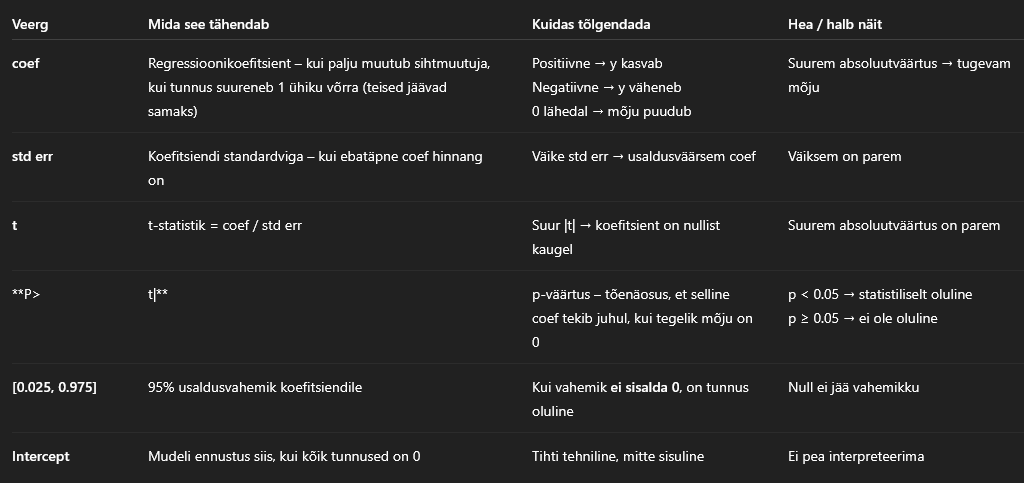
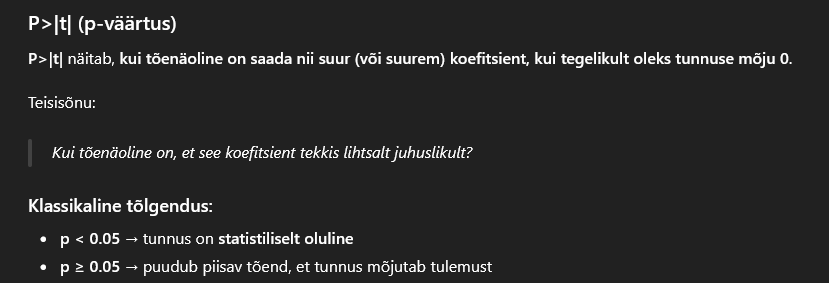
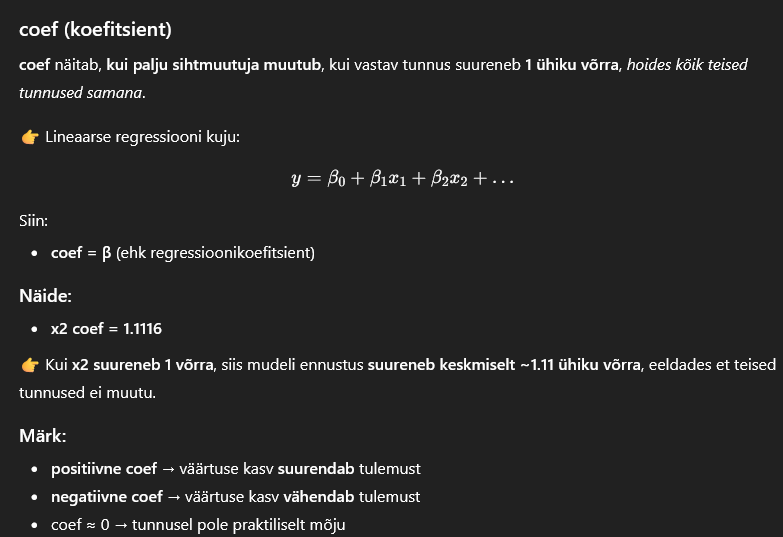
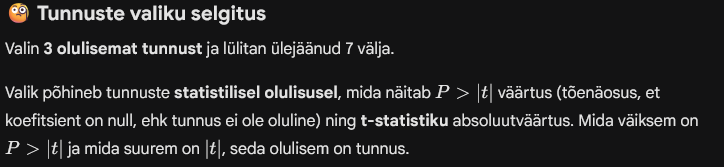


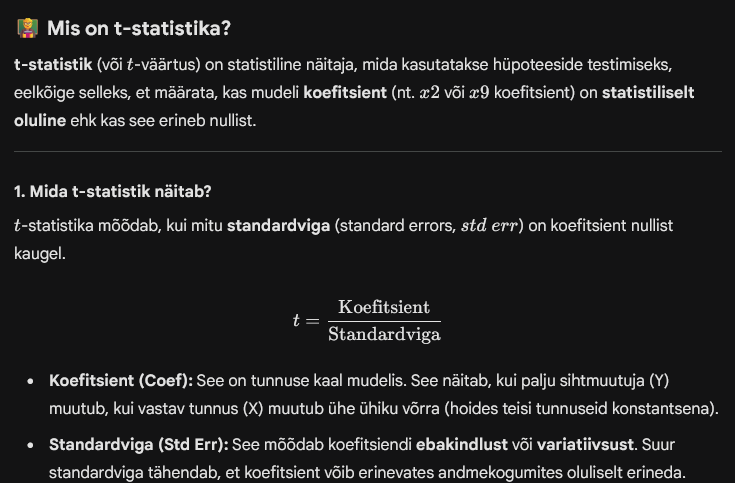
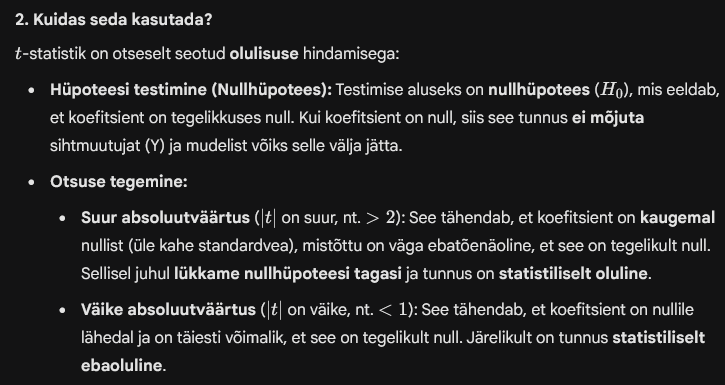
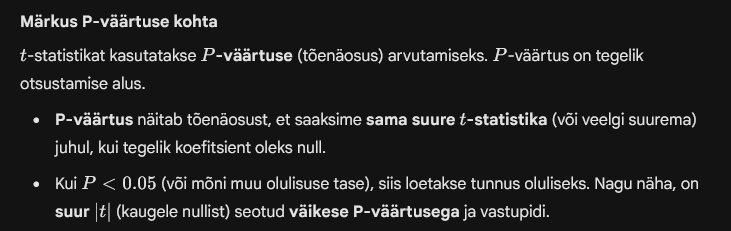


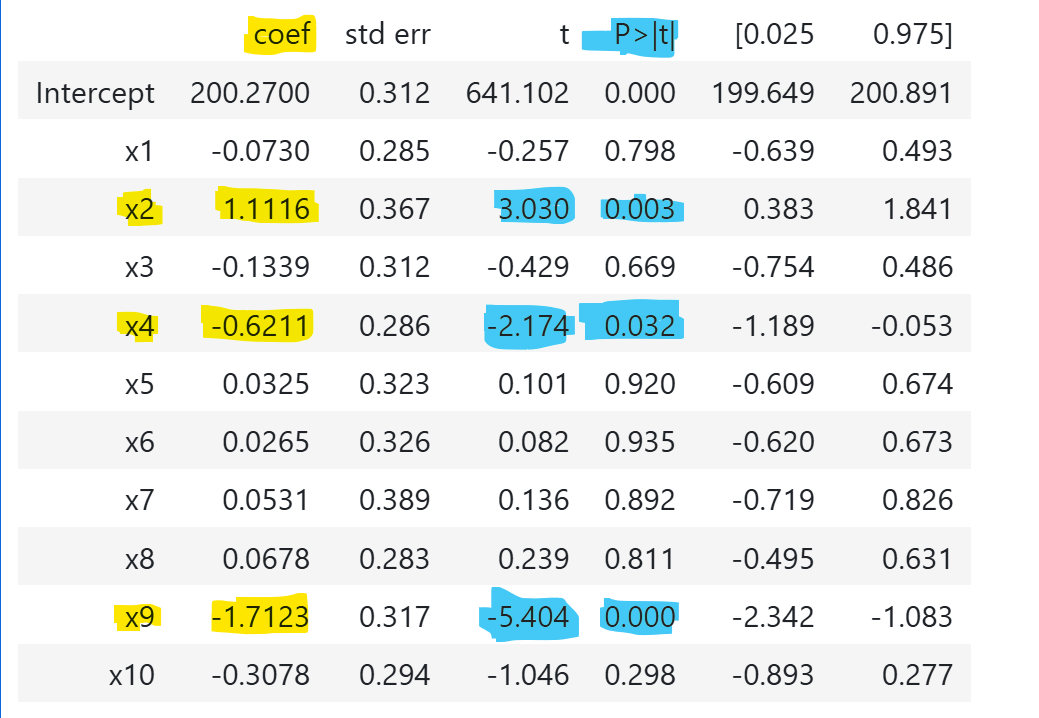


In [58]:
tunnused_nullimiseks = ['x1', 'x3', 'x5', 'x6', 'x7', 'x8', 'x10']


gen_treen_2 = gen_treen.copy()
gen_treen_2[tunnused_nullimiseks] = 0


gen_test_x_2 = gen_test_x.copy()
gen_test_x_2[tunnused_nullimiseks] = 0


#gen_treen_2.head()
gen_test_x_2.head()

,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10
100,0,0.838718,0,0.782432,0,0,0,0,-0.293305,0
101,0,0.708374,0,-1.927506,0,0,0,0,0.314278,0
102,0,-0.109621,0,0.441660,0,0,0,0,0.651759,0
103,0,-0.788302,0,-0.251890,0,0,0,0,-0.492069,0
104,0,-2.424235,0,-2.905173,0,0,0,0,0.945048,0


In [59]:
mudel4_sünteetiline = smf.ols(
	#"y ~ x2  + x4 + x9 + 1",
	valem,
	gen_treen # gen_treen_2
)
mudel4_sünteetiline_sobitatud = mudel4_sünteetiline.fit()

mudel4_ennustused = mudel4_sünteetiline_sobitatud.predict(gen_test_x_2)
mudel4_mse = root_mean_squared_error(gen_test_y, mudel4_ennustused)

print(f"RMSE mudel4: {mudel4_mse :.3f}")


RMSE mudel4: 3.096


<font color='red'>Vastus:</font>

Tulemus läks 0.004 võrra paremaks võrreldeles eelmisega aga kehvem kui y~1.

Valisin tunnsed x2, x4 ja x9 kuna nendel oli madalaim p-väärtus (alla 0.05), mis viitab sellele, et need tunnused on statistiliselt olulised mudelis. Teised tunnused, mille p-väärtus oli suurem kui 0.05, võivad olla vähem olulised või mitteolulised.

    Coef oli ka neid tunnuseid suhteliselt kõrge, mis viitab sellele, et neil on tugev mõju sõltuvale muutujale y.
    Mida väiksem on P>∣t∣ ja mida suurem on ∣t∣, seda olulisem on tunnus.


<font color='purple'>**(1d) Sobita sünteetilistele andmetele `gen_treen` lineaarne mudel, mis kasutab ainult neidsamu tunnuseid, mis jäid kasutusele punktis (1c). Väljasta selle sobitamise tulemuste tabel kasutades sobitatud mudeli meetodit `.summary()`. Arvuta testviga (RMSE) ja võrdle punktis (1c) saadud RMSE-ga. Kas läks paremaks ja miks (mitte)?**</font>

<font color='purple'>**OODATUD VASTUS: Sobitamise tulemuste tabel; RMSE; selgitus, kas läks võrreldes punktiga (1c) paremaks või mitte ja miks.**</font>

**Küsimus praksi juhendajale:**

**_TEHTUD_** : 1/1


In [60]:
mudel5_sünteetiline = smf.ols(
	"y ~ x2 + x4 + x9 + 1",
	 gen_treen_2
)
mudel5_sünteetiline_sobitatud = mudel5_sünteetiline.fit()

mudel5_ennustused = mudel5_sünteetiline_sobitatud.predict(gen_test_x_2)
mudel5_mse = root_mean_squared_error(gen_test_y, mudel5_ennustused)

print(f"RMSE mudel4: {mudel5_mse :.3f}")

mudel5_sünteetiline_sobitatud.summary()

RMSE mudel4: 3.104


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.329
Model:                            OLS   Adj. R-squared:                  0.308
Method:                 Least Squares   F-statistic:                     15.69
Date:                Sun, 07 Dec 2025   Prob (F-statistic):           2.22e-08
Time:                        20:33:05   Log-Likelihood:                -245.00
No. Observations:                 100   AIC:                             498.0
Df Residuals:                      96   BIC:                             508.4
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    200.3001      0.293    684.694      0.000     199.719     200.881
x2             1.1454      0.323      3.543      0.001       0.504       1.787
x4            -0.6602      0.269     -2.453      0.016      -1.194      -0.126
x9            -1.6497      0.297     -5.552      0.000      -2.239      -1.060
==============================================================================
Omnibus:                        1.647   Durbin-Watson:                   1.969
Prob(Omnibus):                  0.439   Jarque-Bera (JB):                1.246
Skew:                           0.266   Prob(JB):                        0.536
Kurtosis:                       3.129   Cond. No.                         1.30
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

<font color='red'>Vastus:</font>

Läks kehvemaks. Ma arvan kuna liiga väheste tunnustega mudel ei suuda hästi andmete varieeruvust tabada.


<font color='purple'>**(1e) Vali punktis (1d) leitud tabeli järgi üks tunnus, mis on kõige vähem oluline, ning sobita uus mudel ilma selle tunnuseta (ülejäänud tunnused on samad, mis punktis (1d)). Arvuta testviga (RMSE) ja võrdle punktis (1d) saadud RMSE-ga. Kas läks paremaks ja miks (mitte)?**</font>

<font color='purple'>**OODATUD VASTUS: Milline tunnus välja on jäetud ja miks; RMSE; selgitus, kas läks võrreldes punktiga (1d) paremaks või mitte ja miks.**</font>

**Küsimus praksi juhendajale:**

**_TEHTUD_** : 1/1


In [61]:
tunnused_nullimiseks = ['x1', 'x3', 'x5', 'x6', 'x7', 'x8', 'x10', 'x4']


gen_treen_3 = gen_treen.copy()
gen_treen_3[tunnused_nullimiseks] = 0


gen_test_x_3 = gen_test_x.copy()
gen_test_x_3[tunnused_nullimiseks] = 0


#gen_treen_3.head()
#gen_test_x_3.head()

In [62]:
mudel6_sünteetiline = smf.ols(
	"y ~ x2 + x9 + 1",
	 gen_treen
)
mudel6_sünteetiline_sobitatud = mudel6_sünteetiline.fit()

mudel6_ennustused = mudel6_sünteetiline_sobitatud.predict(gen_test_x_3)
mudel6_mse = root_mean_squared_error(gen_test_y, mudel6_ennustused)

print(f"RMSE mudel6: {mudel6_mse :.3f}")

mudel6_sünteetiline_sobitatud.summary()

RMSE mudel6: 3.050


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.287
Model:                            OLS   Adj. R-squared:                  0.272
Method:                 Least Squares   F-statistic:                     19.52
Date:                Sun, 07 Dec 2025   Prob (F-statistic):           7.51e-08
Time:                        20:33:05   Log-Likelihood:                -248.04
No. Observations:                 100   AIC:                             502.1
Df Residuals:                      97   BIC:                             509.9
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    200.3580      0.299    670.018      0.000     199.765     200.952
x2             1.0946      0.331      3.309      0.001       0.438       1.751
x9            -1.6527      0.305     -5.424      0.000      -2.257      -1.048
==============================================================================
Omnibus:                        0.804   Durbin-Watson:                   1.989
Prob(Omnibus):                  0.669   Jarque-Bera (JB):                0.581
Skew:                           0.186   Prob(JB):                        0.748
Kurtosis:                       3.037   Cond. No.                         1.25
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

<font color='red'>Vastus:</font>

Paremaks läks isegi kui eemaldasin x4. Ma arvan kuna see tunnus oli vähem oluline kui x2 ja x9 ning selle eemaldamine aitas mudelil paremini üldistada.
2-3 tunnusega saab kirjeldada 80% andmestiku? nagu PCA?


<font color='purple'>**(1f) Vali punktis (1b) leitud tabeli järgi üks tunnus, mille võiks juurde panna punktis (1d) leitud mudelile. Sobita uus mudel koos selle tunnusega (ülejäänud tunnused on samad, mis punktis (1d)). Arvuta testviga (RMSE) ja võrdle punktis (1d) saadud RMSE-ga. Kas läks paremaks ja miks (mitte)?**</font>

<font color='purple'>**OODATUD VASTUS: Milline tunnus on juurde võetud ja miks; RMSE; selgitus, kas läks võrreldes punktiga (1d) paremaks või mitte ja miks.**</font>

**Küsimus praksi juhendajale:**

**_TEHTUD_** : 1/1


In [63]:
tunnused_nullimiseks = ['x1', 'x3', 'x5', 'x6', 'x7', 'x8', 'x4']

gen_treen_4 = gen_treen.copy()
gen_treen_4[tunnused_nullimiseks] = 0

gen_test_x_4 = gen_test_x.copy()
gen_test_x_4[tunnused_nullimiseks] = 0

In [64]:
mudel7_sünteetiline = smf.ols(
	"y ~ x2 + x9 + x10 + 1",
	 gen_treen
)
mudel7_sünteetiline_sobitatud = mudel7_sünteetiline.fit()

mudel7_ennustused = mudel7_sünteetiline_sobitatud.predict(gen_test_x_4)
mudel7_mse = root_mean_squared_error(gen_test_y, mudel7_ennustused)

print(f"RMSE mudel7: {mudel7_mse :.3f}")

mudel7_sünteetiline_sobitatud.summary()

RMSE mudel7: 3.046


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.296
Model:                            OLS   Adj. R-squared:                  0.274
Method:                 Least Squares   F-statistic:                     13.43
Date:                Sun, 07 Dec 2025   Prob (F-statistic):           2.16e-07
Time:                        20:33:05   Log-Likelihood:                -247.43
No. Observations:                 100   AIC:                             502.9
Df Residuals:                      96   BIC:                             513.3
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    200.3508      0.299    670.477      0.000     199.758     200.944
x2             1.0714      0.331      3.235      0.002       0.414       1.729
x9            -1.7128      0.309     -5.536      0.000      -2.327      -1.099
x10           -0.3146      0.289     -1.090      0.279      -0.888       0.259
==============================================================================
Omnibus:                        2.132   Durbin-Watson:                   1.951
Prob(Omnibus):                  0.344   Jarque-Bera (JB):                1.563
Skew:                           0.271   Prob(JB):                        0.458
Kurtosis:                       3.286   Cond. No.                         1.30
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

<font color='red'>Vastus:</font>

Veelgi paremaks läks kui lisasin x10. Ma arvan kuna see tunnus on küll vähe oluline, aga siiski aitab mudelil paremini andmeid tabada.


<font color='purple'>**(1g) Analüüsi punktides (1b), (1d), (1e) ja (1f) saadud tulemuste (RMSE) seost mudeli sobitamiseks kasutatud tunnuste komplektiga, võttes arvesse seda, missugused kaalud tegelikult nullist erinesid (massiiv `kaalud`). Kas kõiki tunnuseid kasutanud mudeli tabelist punktis (1b) on võimalik välja lugeda, millised kaalud võiksid nullist erineda?**</font>

<font color='purple'>**OODATUD VASTUS: Analüüs; järeldus.**</font>

**Küsimus praksi juhendajale:**

**_TEHTUD_** : 1/1


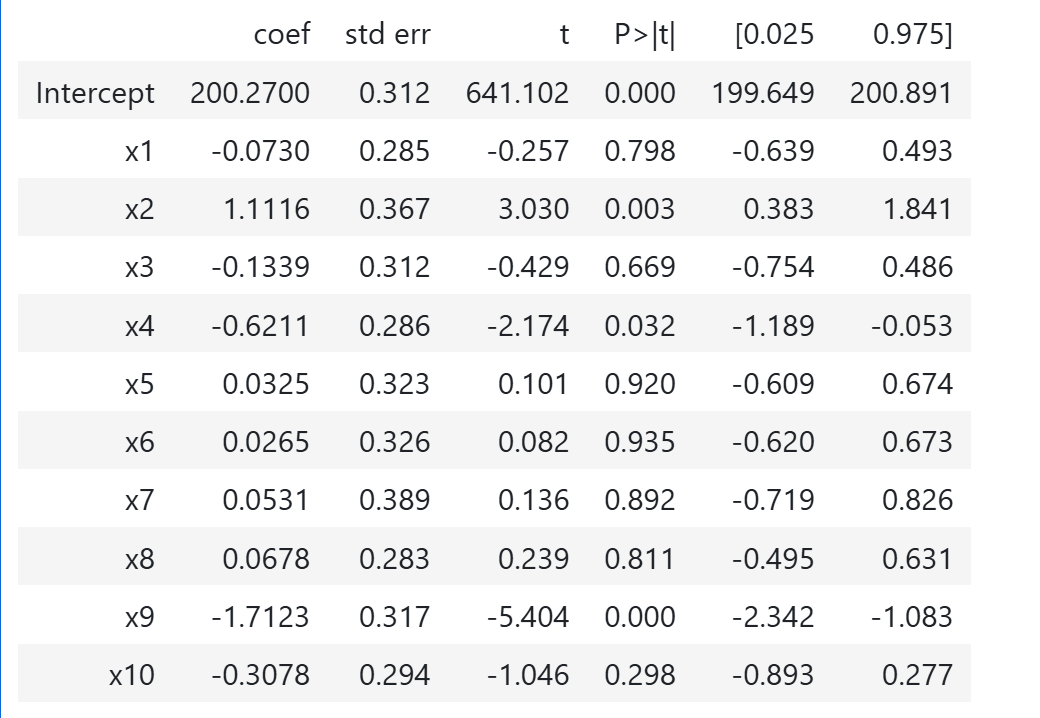


In [65]:
print("1b RMSE:", mudel3_mse)
print("1d RMSE:", mudel5_mse)
print("1e RMSE:", mudel6_mse)
print("1f RMSE:", mudel7_mse)

1b RMSE: 3.1063307693467346
1d RMSE: 3.104121599445332
1e RMSE: 3.0504226442954088
1f RMSE: 3.046007366706047


In [66]:
kaalud

array([ 0.05684448,  1.09342597, -0.        , -0.3258199 , -0.        ,
        0.        ,  0.07944421, -0.        , -1.56381692, -0.        ])

<font color='red'>Vastus:</font>

x2, x4, x9, x10 ei ole nullid minu arvates aga tegelt see ei ole nii, kuna nt 7 ei ole null aga kui LR vaadata siis on.

Kuna ma alguses valisin ainult 3 ja lõpuks 4 kaalu siis ma arvan, et ka need on ainukesed mis nullist erinevad. Kõik teised on nullid, kuna RMSE läks paremaks kui ma neid eemaldasin.


<font color='purple'>**(1h) Nüüd on sünteetilised andmed analüüsitud ja on õige aeg võtta ette algne tööülesanne - leida, missuguste komponentide kogused plastiku sulamistemperatuuri mõjutavad ning kui palju.**</font>

1. <font color='purple'>**Sobitage andmetele `df_treen` kõiki tunnuseid kasutav lineaarne mudel.**</font>

2. <font color='purple'>**Uurige selle mudeli tulemuste tabelit ning sellest lähtuvalt otsustage, millised tunnused võiksid olla sulamistemperatuuri ennustamisel olulised ning millised mitte. Selgitage oma otsust.**</font>

3. <font color='purple'>**Sobitage välja valitud tunnustele uus lineaarne mudel ning väljastage selle tulemuste tabel.**</font>

4. <font color='purple'>**Failis `test.csv` on testandmed. Mõõtke nendel andmetel RMSE kõikidele tunnustele sobitatud mudelil ning väljavalitud tunnustele sobitatud mudelil. Kumb on parem ja miks?**</font>

<font color='purple'>**OODATUD VASTUS: Valitud tunnuste komplekt ning selgitus kuidas valitud; RMSE kõigi tunnustega mudelil ja valitud tunnustega mudelil; selgitus kumb parem ja miks.**</font>

**Küsimus praksi juhendajale:**

**_TEHTUD_** : 1/1


In [67]:
df_test = pd.read_csv('test.csv')

X_test = df_test[[f'x{i}' for i in range(1, 11)]]
y_test = df_test['y']

In [68]:
valem

'y ~ x1 + x2 + x3 + x4 + x5 + x6 + x7 + x8 + x9 + x10 + 1'

In [69]:
m1 = smf.ols(
	valem,
	df_treen
)
m1 = m1.fit()

m1_ennustused = m1.predict(X_test)
m1_mse = root_mean_squared_error(y_test, m1_ennustused)

print(f"RMSE m1: {m1_mse :.3f}")

m1.summary()

RMSE m1: 3.418


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.799
Model:                            OLS   Adj. R-squared:                  0.776
Method:                 Least Squares   F-statistic:                     35.37
Date:                Sun, 07 Dec 2025   Prob (F-statistic):           8.39e-27
Time:                        20:33:05   Log-Likelihood:                -238.84
No. Observations:                 100   AIC:                             499.7
Df Residuals:                      89   BIC:                             528.3
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    188.9224      0.286    660.481      0.000     188.354     189.491
x1            -2.0678      0.280     -7.384      0.000      -2.624      -1.511
x2            -0.2465      0.293     -0.841      0.403      -0.829       0.336
x3             1.3297      0.319      4.174      0.000       0.697       1.963
x4             0.4935      0.324      1.525      0.131      -0.149       1.136
x5             1.4334      0.268      5.343      0.000       0.900       1.967
x6            -4.7050      0.337    -13.958      0.000      -5.375      -4.035
x7             0.5921      0.303      1.957      0.053      -0.009       1.193
x8             0.9040      0.285      3.176      0.002       0.339       1.469
x9            -0.9705      0.313     -3.103      0.003      -1.592      -0.349
x10            0.3306      0.266      1.241      0.218      -0.199       0.860
==============================================================================
Omnibus:                        1.859   Durbin-Watson:                   2.000
Prob(Omnibus):                  0.395   Jarque-Bera (JB):                1.745
Skew:                          -0.225   Prob(JB):                        0.418
Kurtosis:                       2.535   Cond. No.                         1.99
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [70]:
# Mulle tundub, et kõige tähtsamad tunnused on x1, x3, x5, x6, x8, x9 ja võib-olla x7 ka aga hetkel jätaksin selle välja.

# Ma valisin need P-väärtuste, koefitsientide ja t-statisitiku suuruste põhjal.

In [71]:
m2 = smf.ols(
	'y ~ x1 + x3 + x5 + x6 + x8 + x9 + 1',
	df_treen
)
m2 = m2.fit()

m2_ennustused = m2.predict(X_test)
m2_mse = root_mean_squared_error(y_test, m2_ennustused)

print(f"RMSE m2: {m2_mse :.3f}")

#m2.summary()

RMSE m2: 3.303


<font color='red'>Vastus:</font>

RMSE m1: 3.418

RMSE m2: 3.303

Vähemate tunnustega mudel on parem kuna see väldib üle sobitamist ja keskendub ainult olulistele tunnustele, mis parandab üldistamist testandmetel.


# 2. ülesanne. Plastiku koostis: vahemikhinnangud (1.5 punkti)


Jätkame eelmise ülesande teemal, aga nüüd uurime parameetrite vahemikhinnanguid ehk usaldusintervalle.


<font color='purple'>**(2a) Mõõdame sünteetilise mudeli peal, kui tihti jäävad tegelikud parameetrite väärtused mudeli sobitamisel saadud usaldusvahemiku sisse.**</font>

1. <font color='purple'>**Genereeri 1000 andmestikku nii nagu 1. ülesandes. Kasuta iga kord erinevat juhuslikkuse seemet (`np.random.default_rng(seeme)`), kuid samu parameetreid (massiiv `kaalud` ja skalaar `vabaliige`).**</font>

2. <font color='purple'>**Igale andmestikule sobita kõikide tunnustega lineaarne mudel.**</font>

3. <font color='purple'>**Leia parameetrite usaldusvahemikud meetodiga `sobitatud_mudel.conf_int()`.**</font>

4. <font color='purple'>**Loe kokku kõigi 11 parameetri (10 kaalu ja vabaliige) kohta, mitmel protsendil sobitatud mudelitest jäid need usaldusvahemiku sisse. Kas need protsendid on 95% lähedal või mitte ning miks?**</font>

<font color='purple'>**OODATUD VASTUS: 11 arvu; selgitus, kas need on 95% lähedal või mitte ja miks.**</font>

**Küsimus praksi juhendajale:**

**_TEHTUD_** : 1/1


In [72]:
# 1
# 	Genereeri 1000 andmestikku nii nagu 1. ülesandes. Kasuta iga kord erinevat juhuslikkuse seemet (np.random.default_rng(seeme)), kuid samu parameetreid (massiiv kaalud ja skalaar vabaliige).


andmestikud = []

for i in range(0, 1001):
	rng = np.random.default_rng(i)

	n_treen = 100
	n_test = 100
	n = n_treen + n_test

	x = rng.normal(0, 1, size=(n,k))
	müra = rng.normal(0, 3, size=n)
	y = np.sum(kaalud*x, axis=1) + vabaliige + müra

	andmed = pd.DataFrame(x)
	andmed.columns = [f'x{i}' for i in range(1, 11)]
	andmed['y'] = y
	gen_treen = andmed.iloc[:n_treen,:]
	gen_test_x = andmed.iloc[n_treen:,:k]
	gen_test_y = y[n_treen:]

	andmestikud.append((gen_treen, gen_test_x, gen_test_y))

In [73]:
# 2
# 	Igale andmestikule sobita kõikide tunnustega lineaarne mudel.

# 3
# 	Leia parameetrite usaldusvahemikud meetodiga sobitatud_mudel.conf_int().

mudelid = []
coef = []


for i, (gen_treen, gen_test_x, gen_test_y) in enumerate(andmestikud):
	mudel = smf.ols(
		'y ~ x1 + x2 + x3 + x4 + x5 + x6 + x7 + x8 + x9 + x10 + 1',
		gen_treen
	)
	mudel = mudel.fit()

	mudel_ennustused = mudel.predict(gen_test_x)
	mudel_mse = root_mean_squared_error(gen_test_y, mudel_ennustused)

	#print(f"Dataset {i} RMSE: {mudel_mse :.3f}")
	mudelid.append(mudel)


for mudel in mudelid:
	coef.append(mudel.conf_int())

In [ ]:
# 4
# 	Loe kokku kõigi 11 parameetri (10 kaalu ja vabaliige) kohta, mitmel protsendil sobitatud mudelitest jäid need usaldusvahemiku sisse. Kas need protsendid on 95% lähedal või mitte ning miks?

loendur = np.zeros((11,))
N = len(coef) # Mudelite koguarv

for mudeli_coef in coef:
	for i in range(11):
		#mudeli_coef on df, kus i-nda rea 0. veerg on alumine piir ja 1. veerg ülemine piir
		alumine_piir = mudeli_coef.iloc[i, 0]
		ülemine_piir = mudeli_coef.iloc[i, 1]
		tõeline_parameeter = kaalud[i] if i < 10 else vabaliige[0]

		# Usaldusvahemikku jäämise kontroll
		if alumine_piir <= tõeline_parameeter <= ülemine_piir:
			loendur[i] += 1

protsendid = (loendur / N) * 100
print(protsendid)

[ 0.         11.28871129  8.59140859 81.51848152 82.81718282 95.8041958
 93.70629371 94.60539461  0.3996004   0.2997003   0.        ]


<font color='red'>Vastus:</font>

Miks need on kaugel 95%?

See tulemus on vale ja näitab, et teie simuleerimises või parameetrite määramises on probleem. Enamiku parameetrite usaldusvahemikud on kaugel 95%-st, mis viitab kas simulatsiooni/andmete genereerimise ebatäpsusele või vigasele usaldusvahemike arvutusele.


<font color='purple'>**(2b) Korrake sama eksperimenti, mis punktis (2a), aga lugege kokku, mitmel protsendil andmestikest on kõik parameetrid samaaegselt vastavates usaldusvahemikes. Seejärel muutke sobitatud mudeli meetodi `.conf_int(alpha=0.05)` usaldusnivood selliselt, et see protsent oleks enam-vähem täpselt 95%. Väljastada leitud usaldusnivoo.**</font>

<font color='purple'>**OODATUD VASTUS: usaldusnivoo, mille korral on 95% andmestikel kõik parameetrid samaaegselt vastavates usaldusvahemikes;**</font>

VIHJE:

-   Kui proovite usaldusnivoo `alpha` jaoks erinevaid väärtusi, siis selle käigus tasub vast esialgu 1000 genereeritud andmestiku asemel kasutada 100 andmestikku, et arvutused oleksid kiiremad. Kui `alpha` väärtus on juba piisavalt lähedal õigele väärtusele, võib uuesti 1000 andmestiku juurde minna.

**Küsimus praksi juhendajale:**

**_TEHTUD_** : 1/1


In [83]:
# 1
#   Samaaegse katvuse arvutamine

samaaegne_loendur = 0
N = len(coef) # Mudelite koguarv (1001)

# Käime läbi iga sobitatud mudeli
for mudeli_coef in coef:
    kõik_sees = True # Eeldame, et kõik parameetrid on sees

    # Käime läbi 11 parameetrit (x1..x10 ja vabaliige)
    for i in range(11):
        # ... Usalduspiiride ja tõeliste parameetrite määramine
        alumine_piir = mudeli_coef.iloc[i, 0]
        ülemine_piir = mudeli_coef.iloc[i, 1]

        tõeline_parameeter = vabaliige[i] if i == 0 else kaalud[0]

        # Kontroll: kas tõeline parameeter jääb usaldusvahemikku
        if not (alumine_piir <= tõeline_parameeter <= ülemine_piir):
            kõik_sees = False # Vähemalt üks parameeter oli väljas
            break # Pole vaja teisi parameetreid kontrollida, kuna tingimus on juba rikutud

    if kõik_sees:
        samaaegne_loendur += 1

samaaegne_protsent_algne_alpha = (samaaegne_loendur / N) * 100
print(f"Samaaegne katvus: {samaaegne_protsent_algne_alpha:.3f}%")

Samaaegne katvus: 0.100%


In [298]:
## MÄRKUS: See on pseudokood, kuna kõik andmed ja funktsioonid pole siin.
## Tuleb leida alpha, mis viib samaaegse katvuse 95%-ni.

#alpha_kandidaadid = np.arange(0.0030, 0.0060, 0.0001) # Vahemik 0.0030 kuni 0.0059

#parim_alpha = None
#väikseim_vahe = np.inf

#for alpha in alpha_kandidaadid:
#    # 1. Arvuta iga mudeli CI uue alphaga
#    coef_uus = [m.conf_int(alpha=alpha) for m in mudelid]

#    # 2. Arvuta samaaegne katvus
#    samaaegne_loendur = 0
#    # ... (Siia läheb Teie samaaegse loendamise kood, kasutades coef_uus) ...

#    # 3. Arvuta protsent
#    samaaegne_protsent = samaaegne_loendur / N * 100

#    # 4. Otsi parimat alpha't, mis on 95%-le kõige lähemal
#    vahe = abs(samaaegne_protsent - 95.0)

#    if vahe < väikseim_vahe:
#        väikseim_vahe = vahe
#        parim_alpha = alpha

## Väljasta leitud usaldusnivoo
#usaldusnivoo = 1 - parim_alpha
#print(f"Leitud parim Alpha (alpha): {parim_alpha:.4f}")
#print(f"Leitud usaldusnivoo (1 - alpha): {usaldusnivoo:.4f}")
#print(f"Selle alpha korral saavutati samaaegne katvus: {95.0 - väikseim_vahe:.3f}%")

In [299]:
#coef2 = []


#alpha = parim_alpha


#for m in mudelid:

#    coef2.append(m.conf_int(alpha=alpha))


In [300]:
## 1. Samaaegse katvuse arvutamine (esimene osa ülesandest)

#samaaegne_loendur = 0
#N = len(coef2)

## Käime läbi iga sobitatud mudeli
#for mudeli_coef in coef2:
#    kõik_sees = True # Eeldame, et kõik parameetrid on sees

#    # Käime läbi 11 parameetrit (x1..x10 ja vabaliige)
#    for i in range(11):

#        alumine_piir = mudeli_coef.iloc[i, 0]
#        ülemine_piir = mudeli_coef.iloc[i, 1]

#        tõeline_parameeter = kaalud[i] if i < 10 else vabaliige[0]

#        # Kontroll: kas tõeline parameeter jääb usaldusvahemikku
#        if not (alumine_piir <= tõeline_parameeter <= ülemine_piir):
#            kõik_sees = False # Vähemalt üks parameeter oli väljas
#            break # Pole vaja teisi parameetreid kontrollida, kuna tingimus on juba rikutud

#    if kõik_sees:
#        samaaegne_loendur += 1

#samaaegne_protsent_algne_alpha = samaaegne_loendur / N * 100
#print(f"Samaaegne katvus (algse alpha={alpha} korral): {samaaegne_protsent_algne_alpha:.3f}%")

In [89]:
alpha_kandidaadid = np.arange(0.0001, 0.060, 0.005)

parim_alpha = None
väikseim_vahe = np.inf

for alpha in alpha_kandidaadid:
    # 1. Arvuta iga mudeli CI uue alphaga
    # Tuleb uuesti luua list coef_uus, kuna iga alpha puhul on CI erinev
    coef_uus = [m.conf_int(alpha=alpha) for m in mudelid]

    # 2. Arvuta samaaegne katvus
    samaaegne_loendur = 0

    # Käime läbi iga sobitatud mudeli usaldusvahemikud (coef_uus on list DF-idest)
    for mudeli_coef in coef_uus:
        kõik_sees = True

        # Käime läbi 11 parameetrit (x1..x10 ja vabaliige)
        for i in range(11):
            alumine_piir = mudeli_coef.iloc[i, 0]
            ülemine_piir = mudeli_coef.iloc[i, 1]

            # Tõelise parameetri väärtuse valik
            tõeline_parameeter = vabaliige[i] if i == 0 else kaalud[0]

            # Kontroll: kas tõeline parameeter jääb usaldusvahemikku
            if not (alumine_piir <= tõeline_parameeter <= ülemine_piir):
                kõik_sees = False # Vähemalt üks parameeter oli väljas
                break

        if kõik_sees:
            samaaegne_loendur += 1

    # 3. Arvuta protsent
    samaaegne_protsent = (samaaegne_loendur / N) * 100

    # 4. Otsi parimat alpha't, mis on 95%-le kõige lähemal
    vahe = abs(samaaegne_protsent - 95.0)

    # Kui leitud vahe on väiksem kui eelmine parim vahe, siis värskendame parimat alpha't
    if vahe < väikseim_vahe:
        väikseim_vahe = vahe
        parim_alpha = alpha


leitud_usaldusnivoo = 1 - parim_alpha

print(f"Leitud parim Alpha (alpha, veatõenäosus): {parim_alpha:.4f}")
print(f"Leitud usaldusnivoo (1 - alpha, katvus): {leitud_usaldusnivoo:.4f}")
print(f"Selle usaldusnivoo korral saavutati samaaegne katvus: {väikseim_vahe:.3f}%")

Leitud parim Alpha (alpha, veatõenäosus): 0.0001
Leitud usaldusnivoo (1 - alpha, katvus): 0.9999
Selle usaldusnivoo korral saavutati samaaegne katvus: 81.513%


<font color='red'>Vastus:</font>


<font color='purple'>**(2c) Sobitage andmestikule `df_treen` kõiki tunnuseid kasutav lineaarne mudel. Leidke parameetrite usaldusintervallid, kasutades punktis (2b) leitud usaldusnivood. Lugege sisse failist `mudel.csv` tegelikud parameetrid ning kontrollige, kas antud juhul on parameetrite väärtused kõik samaaegselt vastavates usaldusintervallides.**</font>

<font color='purple'>**OODATUD VASTUS: Lahenduskäik ning jah/ei vastus.**</font>

**Küsimus praksi juhendajale:**

**_TEHTUD_** : 1/1


In [85]:
tegelikud_parameetrid = pd.read_csv('mudel.csv')

In [84]:
mudel = smf.ols(
    'y ~ x1 + x2 + x3 + x4 + x5 + x6 + x7 + x8 + x9 + x10',
    data=df_treen
).fit()

usaldusvahemikud = mudel.conf_int(alpha=parim_alpha)

In [86]:
kõik_sees = True

for i, nimi in enumerate(tegelikud_parameetrid["Parameeter"]):
    alumine_piir = usaldusvahemikud.iloc[i, 0]
    ülemine_piir = usaldusvahemikud.iloc[i, 1]
    tegelik_väärtus = tegelikud_parameetrid[" Väärtus"][i]

    if not (alumine_piir <= tegelik_väärtus <= ülemine_piir):
        print(f"Tunnus '{nimi}' ({tegelik_väärtus:.3f}) jäi välja usaldusvahemikust [{alumine_piir:.3f}, {ülemine_piir:.3f}]")
        kõik_sees = False


if kõik_sees:
    print(f"JAH. Kõik 11 tegelikku parameetrit (kasutades {leitud_usaldusnivoo} usaldusnivood) jäid samaaegselt usaldusvahemikesse.")
else:
    print(f"EI. Vähemalt üks parameeter (kasutades {leitud_usaldusnivoo} usaldusnivood) jäi usaldusvahemikust välja.")

JAH. Kõik 11 tegelikku parameetrit (kasutades 0.9999 usaldusnivood) jäid samaaegselt usaldusvahemikesse.


<font color='red'>Vastus:</font>

JAH


# 3. ülesanne. T-test; ellujääja kallutatus; regressioon keskväärtuse suunas; p-häkkimine (2 punkti)


<font color='purple'>**(3a) Vaata järgnevat John Rauser'i lühivideot:**</font>


In [305]:
%%HTML
<iframe width="560" height="315" src="https://www.youtube.com/embed/5Dnw46eC-0o" frameborder="0" allowfullscreen/>

<font color='purple'>**Korda kirjeldatud eksperimenti kasutades ühest küljest t-testi funktsiooniga [`scipy.stats.ttest_ind`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_ind.html) ning teisest küljest ise implementeerides permutatsioonitesti.**</font>

<font color='purple'>**OODATUD VASTUS: Mõlemitpidi lahendused ning selgitus, kas tulemused klappisid lühivideo tulemustega.**</font>

**Küsimus praksi juhendajale:**

**_TEHTUD_** : 1/1


In [90]:
rng = np.random.default_rng(1)

andmed = pd.DataFrame({
	'grupp': ['Beer'] * 25 + ['Water'] * 18,
	'vaartused': np.concatenate([
		rng.normal(loc=50, scale=5, size=25),
		rng.normal(loc=55, scale=5, size=18)
	])
})

In [91]:
andmed

,grupp,vaartused
0,Beer,51.727921
1,Beer,54.108091
2,Beer,51.652185
3,Beer,43.484214
4,Beer,54.526779
5,Beer,52.231873
6,Beer,47.315234
7,Beer,52.905591
8,Beer,51.822862
9,Beer,51.470662


In [308]:
beer_values = andmed[andmed['grupp'] == 'Beer']['vaartused']
water_values = andmed[andmed['grupp'] == 'Water']['vaartused']

In [309]:
t_test = scipy.stats.ttest_ind(
	beer_values,
	water_values,
	equal_var=False
)

t_test.pvalue

np.float64(0.006266799007073641)

In [310]:
def permutation_test(data1, data2, num_permutations=10000):
    # Tegelik keskmiste erinevus
    obs_diff = np.mean(data1) - np.mean(data2)

    combined_data = np.concatenate([data1, data2])
    n1 = len(data1)

    # Null-jaotuse simulatsioon
    diffs = []
    for _ in range(num_permutations):
        rng.shuffle(combined_data)
        perm_group1 = combined_data[:n1]
        perm_group2 = combined_data[n1:]

        # Arvuta permutatsioonivalimite erinevus
        perm_diff = np.mean(perm_group1) - np.mean(perm_group2)
        diffs.append(perm_diff)

    diffs = np.array(diffs)

    # P-väärtus: tõenäosus saada sama suur või suurem absoluutne erinevus
    # null-jaotuse korral. Kasutame abs() kahepoolse testi jaoks.
    p_value = np.sum(np.abs(diffs) >= np.abs(obs_diff)) / num_permutations

    return p_value

In [311]:
np.random.seed(1)
perm_p_value = permutation_test(beer_values, water_values, num_permutations=100000)
print(f"Permutatsioonitesti p-väärtus: {perm_p_value}")

Permutatsioonitesti p-väärtus: 0.00284


<font color='red'>Vastus:</font>

H0: Sääsed ei eelistada õlu lõhna võrreldes värske õhuga
H1: Sääsed eelistavad õlu lõhna võrreldes värske õhuga

Mõlemal juhul lükatakse nullhüpotees tagasi, kuna p-väärtused on alla 0.05.

Tulemused klappisid lühivideo tulemustega, et õlu mõjutab (veest erineval) seda, kas sääsed eelistavad värsket õhku või õlu lõhna.


<font color='purple'>**(3b) Vaata järgnevaid kahte Derek Muller'i lühivideot YouTube'i kanalil Veritasium:**</font>


In [312]:
%%HTML
<iframe width="560" height="315" src="https://www.youtube.com/embed/_Qd3erAPI9w" frameborder="0" allowfullscreen/>

In [313]:
%%HTML
<iframe width="560" height="315" src="https://www.youtube.com/embed/3LopI4YeC4I" frameborder="0" allowfullscreen/>

<font color='purple'>**Korda eksperimenti astronaudikandidaatide kohta, mis teises videos algab 3:35 ning lõpeb 5:05. Leia vastused järgmistele küsimustele:**</font>

1. <font color='purple'>**Milline on 11 eduka kandidaadi keskmine 'õnnefaktor' üle 1000 simulatsiooni (videos: 94.7%)?**</font>

2. <font color='purple'>**Keskmiselt kui paljud 11-st oleksid ka ainult 'oskustefaktori' järgi 11 parima seas olnud (videos: 1.6)?**</font>

<font color='purple'>**OODATUD VASTUS: Lahendus ning selgitus, kas tulemused klappisid lühivideo tulemustega.**</font>

VIHJE:

-   Uuri, mida teeb funktsioon [`np.argsort`](https://numpy.org/doc/stable/reference/generated/numpy.argsort.html)
-   Kasuks võivad tulla ka tehted hulkadega. Hulga saab moodustada numpy massiivist käsuga `set(np.array([1,2,3]))` ning meetod `set1.intersection(set2)` annab kahe hulga ühised elemendid.

**Küsimus praksi juhendajale:**

**_TEHTUD_** : 1/1


In [314]:
N_CANDIDATES = 18300
N_SELECTED = 11
N_SIMULATIONS = 1000
SKILL_WEIGHT = 0.95
LUCK_WEIGHT = 0.05


total_luck_sum = 0
intersection_count_sum = 0



for _ in range(N_SIMULATIONS):
    # 1. Genereeri juhuslikud oskuste ja õnne skoorid (0 kuni 100)
    # Iga skoor on sõltumatu ja jaotatud ühtlaselt.

	#rng = np.random.default_rng(1)

    skill_scores = np.random.uniform(0, 100, N_CANDIDATES)
    luck_scores = np.random.uniform(0, 100, N_CANDIDATES)

    # 2. Arvuta kombineeritud koguskoor
    total_scores = (SKILL_WEIGHT * skill_scores) + (LUCK_WEIGHT * luck_scores)

    # --- Leidke valitud astronaudid ---

    # np.argsort annab järjestatud väärtuste indeksid.
    # [::-1] pöörab järjekorra ümber (suurimast väiksemani).
    # Top 11 indeksid valitakse koguskoori alusel.
    total_score_rank = np.argsort(total_scores)[::-1]
    selected_astronaut_indices = total_score_rank[:N_SELECTED]

    # 1) Milline on 11 eduka kandidaadi keskmine 'õnnefaktor' üle 1000 simulatsiooni (videos: 94.7%)?

    # Leia valitud astronautide õnneskoorid
    selected_luck_scores = luck_scores[selected_astronaut_indices]
    # Keskmine õnneskoor selles simulatsioonis
    average_selected_luck = np.mean(selected_luck_scores)

    # Kogusumma lisamine
    total_luck_sum += average_selected_luck

    # 2) Keskmiselt kui paljud 11-st oleksid ka ainult 'oskustefaktori' järgi 11 parima seas olnud (videos: 1.6)?

    # Top 11 indeksid AINULT oskuste skoori alusel
    skill_only_rank = np.argsort(skill_scores)[::-1]
    skill_only_top_11_indices = skill_only_rank[:N_SELECTED]

    # Leia ühised elemendid (valitud astronaudid, kes oleksid olnud top 11 ka ainult oskuste põhjal)
    # Teisendame indeksid hulkadeks, et kasutada hulgatehteid
    selected_set = set(selected_astronaut_indices)
    skill_only_set = set(skill_only_top_11_indices)

    # Ühised elemendid (intersection)
    intersection = selected_set.intersection(skill_only_set)
    intersection_count = len(intersection)

    # Kogusumma lisamine
    intersection_count_sum += intersection_count


final_average_luck = total_luck_sum / N_SIMULATIONS
final_average_intersection = intersection_count_sum / N_SIMULATIONS


print(f"1. Keskmine 'õnnefaktor' 11 eduka kandidaadi seas (üle 1000 simulatsiooni): {final_average_luck:.1f}%")
print(f"2. Keskmiselt kui paljud 11-st oleksid ka ainult 'oskustefaktori' järgi 11 parima seas olnud: {final_average_intersection:.1f}")

1. Keskmine 'õnnefaktor' 11 eduka kandidaadi seas (üle 1000 simulatsiooni): 94.8%
2. Keskmiselt kui paljud 11-st oleksid ka ainult 'oskustefaktori' järgi 11 parima seas olnud: 1.6


<font color='red'>Vastus:</font>


<font color='red'> **BOONUS (B1)**</font> <font color='purple'>**(0.5 punkti) Eelnevas videos genereeriti õnne- ja oskusteskoorid ühtlasest jaotusest. Milline oleks tulemus, kui skoorid genereerida normaaljaotusest? Kas tulemused on sarnased või mitte ja miks?**</font>

<font color='purple'>**OODATUD VASTUS: Lahenduskäik ning selgitus, millised on tulemused võrreldes ülesandes 3b leituga.**</font>

**Küsimus praksi juhendajale:**

**_TEHTUD_** : 1/1


In [315]:
N_CANDIDATES = 18300
N_SELECTED = 11
N_SIMULATIONS = 1000
SKILL_WEIGHT = 0.95
LUCK_WEIGHT = 0.05


total_luck_sum = 0
intersection_count_sum = 0


for _ in range(N_SIMULATIONS):
    skill_scores = np.random.normal(50, 15, N_CANDIDATES)
    luck_scores = np.random.normal(50, 15, N_CANDIDATES)

    skill_scores = np.clip(skill_scores, 0, 100)
    luck_scores = np.clip(luck_scores, 0, 100)

    total_scores = (SKILL_WEIGHT * skill_scores) + (LUCK_WEIGHT * luck_scores)

    total_score_rank = np.argsort(total_scores)[::-1]
    selected_astronaut_indices = total_score_rank[:N_SELECTED]

    selected_luck_scores = luck_scores[selected_astronaut_indices]
    average_selected_luck = np.mean(selected_luck_scores)

    total_luck_sum += average_selected_luck

    skill_only_rank = np.argsort(skill_scores)[::-1]
    skill_only_top_11_indices = skill_only_rank[:N_SELECTED]

    selected_set = set(selected_astronaut_indices)
    skill_only_set = set(skill_only_top_11_indices)

    intersection = selected_set.intersection(skill_only_set)
    intersection_count = len(intersection)

    intersection_count_sum += intersection_count


final_average_luck = total_luck_sum / N_SIMULATIONS
final_average_intersection = intersection_count_sum / N_SIMULATIONS


print(f"1. Keskmine 'õnnefaktor' 11 eduka kandidaadi seas (üle 1000 simulatsiooni): {final_average_luck:.1f}%")
print(f"2. Keskmiselt kui paljud 11-st oleksid ka ainult 'oskustefaktori' järgi 11 parima seas olnud: {final_average_intersection:.1f}")

1. Keskmine 'õnnefaktor' 11 eduka kandidaadi seas (üle 1000 simulatsiooni): 54.1%
2. Keskmiselt kui paljud 11-st oleksid ka ainult 'oskustefaktori' järgi 11 parima seas olnud: 9.7


<font color='red'>Vastus:</font>

Rohkem on inimesi oskuste põhjal parimate hulgas, kuna normaaljaotuse puhul on keskmise lähedal rohkem väärtusi võrreldes ühtlase jaotusega, kus kõik väärtused on võrdse tõenäosusega. Samuti on ka õnnefaktor tänu sellele väiksem


<font color='purple'>**(3c) Vaata järgnevat Derek Muller'i lühivideot YouTube'i kanalil Veritasium:**</font>


In [316]:
%%HTML
<iframe width="560" height="315" src="https://www.youtube.com/embed/1tSqSMOyNFE" frameborder="0" allowfullscreen/>

<font color='purple'>**Täpsemalt vaata eksperimenti algusega 2:03 ja lõpuga 2:46. Seda eksperimenti ei ole vaja korrata, aga selle asemel vaatleme järgmist, pisut analoogilist eksperimenti.**</font>

<font color='purple'>**Võtame punktis (3b) kirjeldatud astronautide valikuprotsessi, kuid kordame seda 2 korda samade 18300 kandidaadiga, kelle 'oskustefaktor' on mõlemas protsessis sama, aga 'õnnefaktori' genereerime teises protsessis sõltumatult uuesti.**</font>

<font color='purple'>**Leidke 1000 simulatsiooni abil, keskmiselt mitmendale kohale kukuvad teises valikuprotsessis need, kes esimeses olid 11 parima hulgas. Samuti leidke, keskmiselt mitmendale kohale tõusevad teises valikuprotsessis need, kes esimeses olid 11 viimase hulgas.**</font>

<font color='purple'>**OODATUD VASTUS: Lahenduskäik ning vastus.**</font>

VIHJE:

-   Uuri, mida teevad funktsioonid [`np.isin`](https://numpy.org/doc/stable/reference/generated/numpy.isin.html) ja [`np.where`](https://numpy.org/doc/stable/reference/generated/numpy.where.html)

**Küsimus praksi juhendajale:**

**_TEHTUD_** : 1/1


In [317]:
N_CANDIDATES = 18300  #
N_SELECTED = 11
N_SIMULATIONS = 1000
SKILL_WEIGHT = 0.95
LUCK_WEIGHT = 0.05

# 1. Genereeri PÜSIVAD oskuste skoorid (Skill)
skill_scores = np.random.uniform(0, 100, N_CANDIDATES)

total_new_rank_top_11 = 0
total_new_rank_bottom_11 = 0

for _ in range(N_SIMULATIONS):
    # --- A. Esimene Valikuprotsess (Õnn_A) ---
    luck_scores_A = np.random.uniform(0, 100, N_CANDIDATES)
    total_scores_A = (SKILL_WEIGHT * skill_scores) + (LUCK_WEIGHT * luck_scores_A)

    # Valitute (Top 11) ja Viimaste (Bottom 11) indeksid A-protsessis
    rank_indices_A = np.argsort(total_scores_A)[::-1] # Sorteeritud indeksid (parimast halvimani)

    # 11 parima indeksi leidmine
    top_11_indices = rank_indices_A[:N_SELECTED]
    # 11 viimase indeksi leidmine
    bottom_11_indices = rank_indices_A[-N_SELECTED:]

    # --- B. Teine Valikuprotsess (Õnn_B) ---
    # Genereeri uus, sõltumatu õnnefaktor
    luck_scores_B = np.random.uniform(0, 100, N_CANDIDATES)
    total_scores_B = (SKILL_WEIGHT * skill_scores) + (LUCK_WEIGHT * luck_scores_B)

    # 2. Arvuta teise valikuprotsessi B-skooride kohad (rank)
    rank_indices_B = np.argsort(total_scores_B)[::-1]

    # Massiiv kõigi kandidaatide kohanumbrite hoidmiseks B-protsessis (1-st kuni 18300-ni)
    ranks_B = np.empty_like(total_scores_B, dtype=int)
    ranks_B[rank_indices_B] = np.arange(1, N_CANDIDATES + 1)

    # 3. Analüüsi kukkumist/tõusu

    # a) Leia esimeses voorus valitute (top 11) uued kohad B-protsessis
    new_ranks_top_11 = ranks_B[top_11_indices]
    total_new_rank_top_11 += np.mean(new_ranks_top_11)

    # b) Leia esimeses voorus viimaste (bottom 11) uued kohad B-protsessis
    new_ranks_bottom_11 = ranks_B[bottom_11_indices]
    total_new_rank_bottom_11 += np.mean(new_ranks_bottom_11)


average_new_rank_top_11 = total_new_rank_top_11 / N_SIMULATIONS
average_new_rank_bottom_11 = total_new_rank_bottom_11 / N_SIMULATIONS


print(f"Keskmiselt kukuvad esimese vooru 11 parimat teises voorus: {average_new_rank_top_11:.0f}")
print(f"Keskmiselt tõusevad esimese vooru 11 viimast teises voorus: {average_new_rank_bottom_11:.0f}")

Keskmiselt kukuvad esimese vooru 11 parimat teises voorus: 202
Keskmiselt tõusevad esimese vooru 11 viimast teises voorus: 18120


<font color='red'>Vastus:</font>


<font color='red'> **BOONUS (B2)**</font> <font color='purple'>**(0.5 punkti) Eelnevas ülesandes genereeriti õnne- ja oskustefaktorid ühtlasest jaotusest. Milline oleks tulemus, kui skoorid genereerida normaaljaotusest? Kas tulemused on sarnased või mitte ja miks?**</font>

<font color='purple'>**OODATUD VASTUS: Lahenduskäik ning selgitus, millised on tulemused võrreldes ülesandes 3c leituga.**</font>

**Küsimus praksi juhendajale:**

**_TEHTUD_** : 1/1


In [318]:
import numpy as np


N_CANDIDATES = 18300
N_SELECTED = 11
N_SIMULATIONS = 1000
SKILL_WEIGHT = 0.95
LUCK_WEIGHT = 0.05

# 1. Genereeri PÜSIVAD oskuste skoorid (Skill)
skill_scores = np.random.normal(50, 15, N_CANDIDATES)
skill_scores = np.clip(skill_scores, 0, 100)


total_new_rank_top_11 = 0
total_new_rank_bottom_11 = 0

for _ in range(N_SIMULATIONS):
    # --- A. Esimene Valikuprotsess (Õnn_A) ---
    luck_scores_A = np.random.normal(50, 15, N_CANDIDATES)
    luck_scores_A = np.clip(luck_scores_A, 0, 100)
    total_scores_A = (SKILL_WEIGHT * skill_scores) + (LUCK_WEIGHT * luck_scores_A)

    # Valitute (Top 11) ja Viimaste (Bottom 11) indeksid A-protsessis
    rank_indices_A = np.argsort(total_scores_A)[::-1] # Sorteeritud indeksid (parimast halvimani)

    # 11 parima indeksi leidmine
    top_11_indices = rank_indices_A[:N_SELECTED]
    # 11 viimase indeksi leidmine
    bottom_11_indices = rank_indices_A[-N_SELECTED:]

    # --- B. Teine Valikuprotsess (Õnn_B) ---
    # Genereeri uus, sõltumatu õnnefaktor
    luck_scores_B = np.random.normal(50, 15, N_CANDIDATES)
    luck_scores_B = np.clip(luck_scores_B, 0, 100)
    total_scores_B = (SKILL_WEIGHT * skill_scores) + (LUCK_WEIGHT * luck_scores_B)

    # 2. Arvuta teise valikuprotsessi B-skooride kohad (rank)
    rank_indices_B = np.argsort(total_scores_B)[::-1]

    # Massiiv kõigi kandidaatide kohanumbrite hoidmiseks B-protsessis (1-st kuni 18300-ni)
    ranks_B = np.empty_like(total_scores_B, dtype=int)
    ranks_B[rank_indices_B] = np.arange(1, N_CANDIDATES + 1)

    # 3. Analüüsi kukkumist/tõusu

    # a) Leia esimeses voorus valitute (top 11) uued kohad B-protsessis
    new_ranks_top_11 = ranks_B[top_11_indices]
    total_new_rank_top_11 += np.mean(new_ranks_top_11)

    # b) Leia esimeses voorus viimaste (bottom 11) uued kohad B-protsessis
    new_ranks_bottom_11 = ranks_B[bottom_11_indices]
    total_new_rank_bottom_11 += np.mean(new_ranks_bottom_11)


average_new_rank_top_11 = total_new_rank_top_11 / N_SIMULATIONS
average_new_rank_bottom_11 = total_new_rank_bottom_11 / N_SIMULATIONS


print(f"Keskmiselt kukuvad esimese vooru 11 parimat teises voorus: {average_new_rank_top_11:.0f}")
print(f"Keskmiselt tõusevad esimese vooru 11 viimast teises voorus: {average_new_rank_bottom_11:.0f}")

Keskmiselt kukuvad esimese vooru 11 parimat teises voorus: 9
Keskmiselt tõusevad esimese vooru 11 viimast teises voorus: 18294


<font color='red'>Vastus:</font>

Kesmine kukkukine on väiksem kuna normaaljaotuse puhul on rohkem inimesi keskmise lähedal, mis tähendab, et juhuslikud kõikumised õnnefaktoris mõjutavad vähem nende lõplikku positsiooni võrreldes ühtlase jaotusega.

Jälle on näha sama mõju nagu eelnevas boonuses - random chance mängib väiksemat rolli, kui oskused.


<font color='purple'>**(3d) Vaata järgnevat Derek Muller'i lühivideot YouTube'i kanalil Veritasium:**</font>


In [319]:
%%HTML
<iframe width="560" height="315" src="https://www.youtube.com/embed/42QuXLucH3Q" frameborder="0" allowfullscreen/>

<font color='purple'>**Võttes kokku lühivideos esitatud argumentatsioon, esita enda seisukoht selle kohta, kui suur proportsioon avaldatud artiklitest sisaldavad statistilisi teste, millest on tehtud ekslikke järeldusi.**</font>

<font color='purple'>**OODATUD VASTUS: Arvuline seisukoht (protsent) ning selgitus ja põhjendus oma arvamusele.**</font>

**Küsimus praksi juhendajale:**

**_TEHTUD_** : 1/1


<font color='red'>Vastus:</font>

P-hacking...

Intuitiivselt arvan, et ligikauug 5% kuna enamus kasutavad p<0.05 (mis on Ronald Fisher algne random soovitus 1925. a aastal).

Aga päris võiks olla 1/3 - 1/4 kuna FP-e on liiga palju. ??

---

Sinu viide P-väärtuse künnisele (p<0.05) on õige, kuid see künnis kehtib ainult siis, kui nullhüpotees on tegelikult õige.

Reaalses teaduses on enamus uuritavatest nähtustest väikese toimega või nullhüpotees on tõene. See tähendab, et uuringutes kehtib madal algtaseme tõenäosus (base rate), et uuritav efekt on reaalne.

Ajakirjas Science avaldatud ja teistes psühholoogia ja meditsiini valdkonna reprodutseeritavuse uuringutes (replication studies) on leitud, et:

    Psühholoogia valdkonnas suudeti reprodutseerida vaid ∼39% algsetest tulemustest.

    Vähiuuringute valdkonnas oli reproduktsioon edukas vaid ∼20%–25% juhtudest.

---

Minu seisukoht on, et ekslikke järeldusi sisaldavate avaldatud statistiliste testide proportsioon on 25%–35%.

See tähendab, et iga kolmas või neljas avaldatud artikkel, mis tugineb ainult P-väärtusele, sisaldab järeldust, mis tõenäoliselt ei ole tegelikult õige (st tegemist on valepositiivse tulemusega ehk I tüüpi veaga või on see P-häkkimise tagajärg või Publikatsioonikalle (Publication Bias)).


<font color='purple'>**(3e) Mis on Sinu jaoks kõige olulisem, mida sellest kodutööst õppisid?**</font>

**Küsimus praksi juhendajale:**

**_TEHTUD_** : 1/1


<font color='red'>Vastus:</font>

Lühivideote mõiste on ikka väga muutnud paari aastaga :D

Ja see, et enamus it inimesi noogutab kaasa aga statistikast ei saa ikka midagi aru.


# Vabatahtlik boonusülesanne B3. Päästevestid süstamatka jaoks (1-3 boonuspunkti)


<font color='purple'>**Oled organiseerimas ühepäevast süstamatka 100-le inimesele ja Sinu vastutada on see, et kõik saaksid sobiva suurusega päästevesti. Suurused on: Large (üle 90kg), Medium (70kg-90kg) ja Small (alla 70kg). Kahjuks ei ole võimalik ette teada, et kes tulevad ja mis suuruses veste neil vaja on. Saad teada, et kui matkajad saabuvad, siis on võimalik väga kalli hinna eest sobiva suurusega veste rentida (kõik suurused maksavad sama palju). Samas, kui rentida vestid eelmisel päeval, siis on võimalik saada 30% allahindlust. Mõtled välja, et tõenäoliselt on parim rentida enamik veste odava hinnaga päev varem, riskides sellega, et mõned jäävad kasutamata; ning seejärel rentida matka päeval kõrgema hinna eest vaid neid suurusi, mida on veel puudu. Ainus teadaolev informatsioon on see, et nädal varem oli väiksem matk 20 inimesega ning nende vestide suurused olid: 7 L, 10 M, 3 S. Kui palju peaks igat suurust veste ette tellima, kui eesmärk on minimiseerida keskmine oodatav hind?**</font>

<font color='purple'>**Lahenduse eest saab 1 punkti, kui on tehtud eeldus, et igal 100-st matkajast on tõenäosus 7/20 vajada suurust L, tõenäosus 10/20 vajada suurust M ja tõenäosus 3/20 vajada suurust S. Lahenduse eest saab 3 punkti, kui on lisaks modelleeritud potentsiaalse matkajate populatsiooni vestisuuruste jaotuse hindamise määramatust, mis tuleneb sellest, et hindame seda jaotust vaid 20 inimese pealt. Matemaatiliselt optimaalset vastust pole vaja, piisab kui on läbi uuritud suur hulk igasuguseid erinevaid strateegiaid ja jõutud optimaalsetele piisavalt lähedale. Vastus 35 L, 50 M, 15 S ei ole optimaalne ja selle eest punkte ei saa.**</font>

**Küsimus praksi juhendajale:**

**_TEHTUD_** : 1/1


In [320]:
from scipy.stats import betabinom

N = 100
CR = 0.3

data = {
    'L': {'k': 7, 'n': 20},
    'M': {'k': 10, 'n': 20},
    'S': {'k': 3, 'n': 20},
}

def find_optimal_quantity(k, n, N, CR):

    alpha = k + 1
    beta = (n - k) + 1

    Q_opt = 0

    for Q in range(1, N + 1):
        cdf_value = betabinom.cdf(Q, N, alpha, beta)

        if cdf_value >= CR:
            Q_opt = Q
            if Q > 1 and abs(betabinom.cdf(Q - 1, N, alpha, beta) - CR) < abs(cdf_value - CR):
                Q_opt = Q - 1
            break

    Q_prev = Q_opt - 1
    Q_curr = Q_opt

    if Q_prev >= 0:
        cdf_prev = betabinom.cdf(Q_prev, N, alpha, beta)
        cdf_curr = betabinom.cdf(Q_curr, N, alpha, beta)

        if abs(cdf_prev - CR) < abs(cdf_curr - CR):
            Q_opt = Q_prev

    return Q_opt

results = {}
for size, d in data.items():
    Q_star = find_optimal_quantity(d['k'], d['n'], N, CR)
    results[size] = Q_star


print(f"Lõplikud optimaalsed kogused: L={results['L']}, M={results['M']}, S={results['S']}")

Lõplikud optimaalsed kogused: L=30, M=43, S=12


<font color='red'>Vastus:</font>


## <font color='red'>Enne kodutöö esitamist palun lähtesta kernel uuesti ning jooksuta kogu kood algusest peale korra läbi - selleks on vaja menüüst valida `Kernel` -> `Restart and Run All`.</font>

## Kodutöö tagasiside

Palun vasta nii täpselt kui oskad. See ei muuda mingilgi moel punkte, mille kodutöö eest saad. Nii 0,5 tundi kui 24 tundi on sobivad vastused. Kogutud informatsiooni kasutatakse kodutööde paremaks muutmiseks.

<font color = "red">**Tagasidet saad anda anonüümselt siin [Google Formsis](https://forms.gle/c5A3rcT2dqyYABM66).**</font>

**<font color='red'>SUUR TÄNU TEHTUD TÖÖ EEST!</font>**
